In [6]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field

In [3]:
load_dotenv()

True

In [4]:
model = ChatGoogleGenerativeAI(model='gemini-flash-latest')

In [7]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description="Sentiment of the review")
    

In [22]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [23]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [9]:
prompt = "The software is working too slow."
structured_model.invoke(prompt).sentiment

'negative'

In [10]:
class ReviewState(TypedDict):
    review : str
    sentiment : Literal['positive','negative']
    diagnosis : dict

    response : str


In [12]:
def find_sentiment(state:ReviewState):
    review = state['review']
    prompt = f"For the following review found out the sentiment \n {review}"
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment':sentiment}

In [20]:
def check_sentiment(state:ReviewState)->Literal['run_diagnosis','positive_response']:
    sentiment = state['sentiment']
    if sentiment == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"
    

In [31]:
def positive_response(state:ReviewState):
    prompt = f"""Write a warn thank you message in response to this review: \n\n\"{state['review']}.Also kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).text
    return {'response':response}

def run_diagnosis(state:ReviewState):
    prompt = f"""Diagnose this negative review: \n\n\"{state['review']}.Return issue type, tone and urgency."""
    response = structured_model2.invoke(prompt)
    return {'diagnosis':response.model_dump()}

def negative_response(state:ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).text
    return {'response':response}


In [32]:
# make a graph
graph = StateGraph(ReviewState)

# add node
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)


# add edge
graph.add_edge(START,'find_sentiment')
graph.add_edge('find_sentiment',END)
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

# compile
workflow = graph.compile()

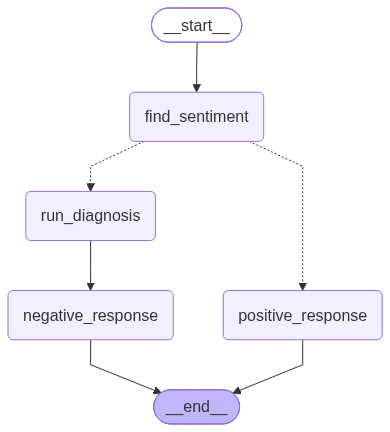

In [33]:
workflow

In [34]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': 'Subject: Resolved: Update on your high-priority report regarding [Issue/Feature Name]\n\nHi [User Name],\n\nThank you for reaching out to us, and I want to sincerely apologize for the frustration this bug caused you. We know how critical this was for you, and given the high urgency of your ticket, our engineering team prioritized getting this fixed as quickly as possible.\n\nI’m glad to let you know that the bug has been successfully resolved. [Brief explanation if applicable: We identified an issue causing X and have deployed a fix to correct it.]\n\n**Next Steps:**\nTo ensure the fix is applied on your end, please try the follo